In [1]:
import keras
import numpy as np
import torchvision

# MNIST dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                          train=False,
                                          transform=transform)

X_train = train_dataset.data
y_train = np.array(train_dataset.targets)

X_test = test_dataset.data
y_test = np.array(test_dataset.targets)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y_train))

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

train = X_train, y_train_cat
test = X_test, y_test_cat

print(f"Размер тренировочных данных: {X_train.shape}")
print(f"Размер тестовых данных: {X_test.shape}")
print(f"Метки классов: {np.unique(y_train)}")


/home/zab/Git/ML_Course_PT/Hometasks/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Размер тренировочных данных: (50000, 32, 32, 3)
Размер тестовых данных: (10000, 32, 32, 3)
Метки классов: [0 1 2 3 4 5 6 7 8 9]


In [37]:
from keras.src.callbacks import EarlyStopping, ReduceLROnPlateau
from matplotlib import pyplot as plt

def train_and_evaluate_model(model, train, test, val=None, epochs=10, batch_size=32, optimizer='adam'):
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    X_train, y_train_cat = train
    X_test, y_test_cat = test

    callbacks = None

    if val is not None:
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max', verbose=1),
            ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=0.1e-7, mode='max', verbose=1),
        ]

    history = model.fit(
        X_train, y_train_cat,
        validation_data=val,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\nТестовая точность: {test_accuracy:.4f}")
    print(f"Тестовая потеря: {test_loss:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    if val is not None:
        axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Точность модели')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Точность')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    if val is not None:
        axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Потери модели')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Потери')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return model


I0000 00:00:1773441073.263998 1934730 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11781 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0
I0000 00:00:1773441073.265114 1934730 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4564 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:03:00.0, compute capability: 7.5


Epoch 1/10


2026-03-14 01:31:14.372302: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f6d74005e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-14 01:31:14.372317: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2026-03-14 01:31:14.372320: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-03-14 01:31:14.383486: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-14 01:31:14.441043: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-14 01:31:14.815913: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141',

 167/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.1580 - loss: 732.9503

I0000 00:00:1773441075.793954 1934803 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1545/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.1496 - loss: 153.1597

2026-03-14 01:31:17.236823: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:31:17.553877: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 4 bytes spill stores, 4 bytes spill loads

2026-03-14 01:31:17.914947: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 176 bytes spill stores, 176 bytes spill loads

2026-03-14 01:31:17.994961: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_141', 140 byte

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1212 - loss: 34.5713 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.0982 - loss: 2.3027
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 894us/step - accuracy: 0.0986 - loss: 2.3024
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.0986 - loss: 2.3039
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step - accuracy: 0.1004 - loss: 2.3041
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.0978 - loss: 2.3028
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 896us/step - accuracy: 0.0984 - loss: 2.3026
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - accuracy: 0.0980 - loss: 2.3027
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.0968 - loss: 2.3089
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step - accuracy: 0.0985 - loss: 2.3029

Тестовая точность: 0.0998
Тестовая потеря: 2.3039


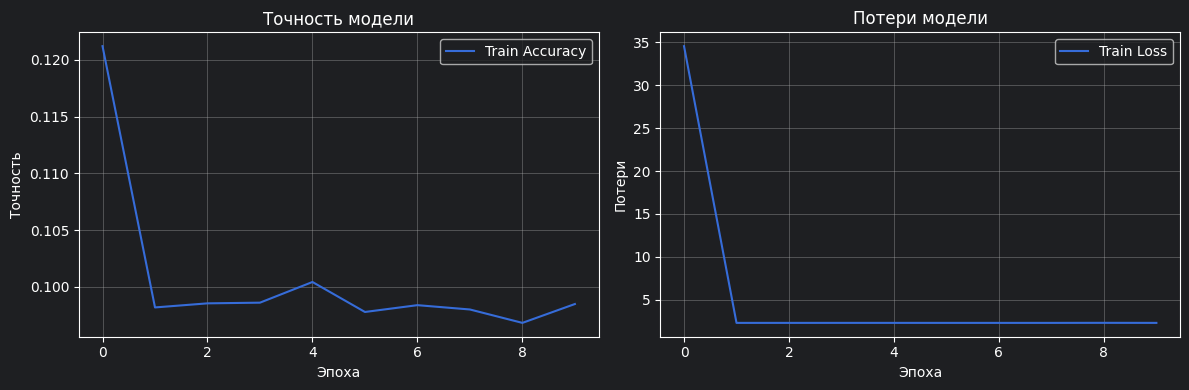

In [3]:
# TASK 1: baseline model but in tensorflow

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1000, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

train_and_evaluate_model(build_model(), train, test);

Epoch 1/10
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - accuracy: 0.1044 - loss: 66.0815

2026-03-14 01:31:36.450880: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:31:36.450899: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:31:36.450913: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:31:37.502151: I external/l

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0999 - loss: 14.6081
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 958us/step - accuracy: 0.1013 - loss: 2.3028
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - accuracy: 0.1000 - loss: 2.3028
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 953us/step - accuracy: 0.0986 - loss: 2.3028
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.1010 - loss: 2.3027
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - accuracy: 0.0955 - loss: 2.3028
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 953us/step - accuracy: 0.0981 - loss: 2.3028
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 951us/step - accuracy: 0.0977 - loss: 2.3028
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.0983 - loss: 2.3028
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 944us/step - accuracy: 0.0997 - loss: 2.3028

Тестовая точность: 0.1000
Тестовая потеря: 2.3026


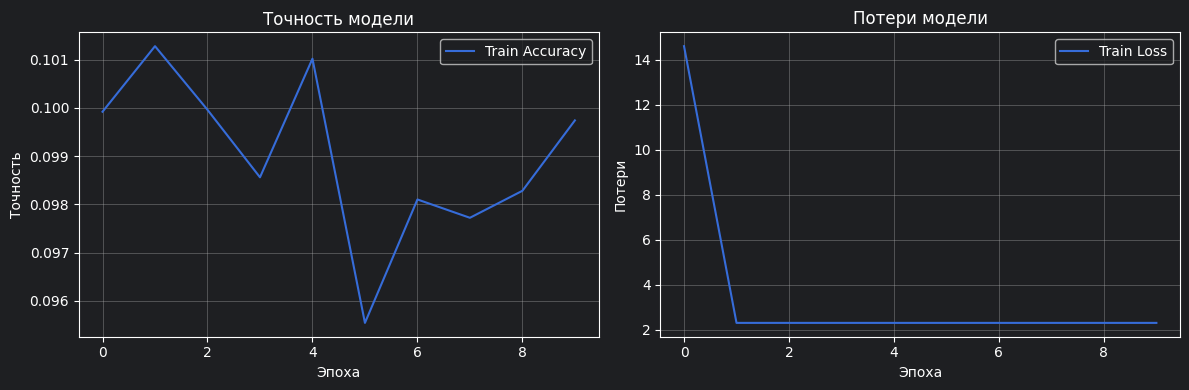

In [4]:
# TASK 2: additional dense layer

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1000, activation='relu')(x)
    x = layers.Dense(100, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

train_and_evaluate_model(build_model(), train, test);

Epoch 1/10


2026-03-14 01:31:55.300170: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:31:55.300213: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:31:55.988326: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_298', 4 bytes spill stores, 4 bytes spill loads

2026-03-14 01:31:56.333060: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

1533/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2239 - loss: 27.1373

2026-03-14 01:32:00.244269: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 01:32:01.233690: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_305', 88 bytes spill stores, 96 bytes spill loads

2026-03-14 01:32:01.804640: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_305', 4 bytes spill stores, 4 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.2707 - loss: 7.0646 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3257 - loss: 1.8839
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3321 - loss: 1.8508
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3581 - loss: 1.7902
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3757 - loss: 1.7392
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3875 - loss: 1.7129
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3955 - loss: 1.6832
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4038 - loss: 1.6656
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4158 - loss: 1.6370
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4259 - loss: 1.6201

Тестовая точность: 0.3998
Тестовая потеря: 1.6782


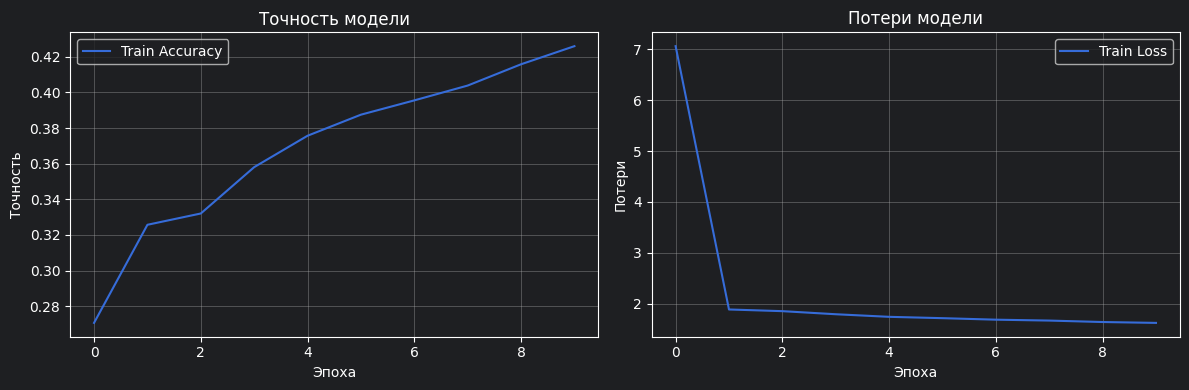

In [5]:
# TASK 3: more additional dense layers

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

train_and_evaluate_model(build_model(), train, test);

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.1626 - loss: 5.8099 
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1654 - loss: 2.1717
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1587 - loss: 2.1718
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1699 - loss: 2.1492
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1827 - loss: 2.1265
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1994 - loss: 2.1066
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2081 - loss: 2.0831
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2061 - loss: 2.0666
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2101 - loss: 2.0478
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2159 - loss: 2.0338

Тестовая точность: 0.2179
Тестовая потеря: 2.0282


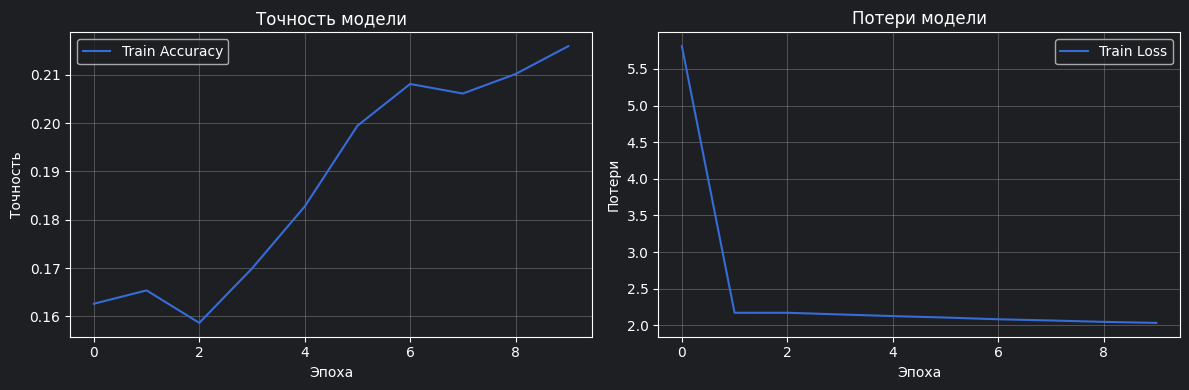

In [6]:
# TASK 4: dropouts

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

train_and_evaluate_model(build_model(), train, test);

Epoch 1/10


2026-03-14 01:32:47.408253: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 116 bytes spill stores, 116 bytes spill loads

2026-03-14 01:32:47.494184: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 776 bytes spill stores, 772 bytes spill loads



1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3301 - loss: 1.8645

2026-03-14 01:32:51.263902: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 12 bytes spill stores, 12 bytes spill loads

2026-03-14 01:32:51.482031: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_935', 776 bytes spill stores, 772 bytes spill loads



1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3750 - loss: 1.7403
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4529 - loss: 1.5323
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4933 - loss: 1.4218
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5243 - loss: 1.3387
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5475 - loss: 1.2709
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5741 - loss: 1.2028
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5950 - loss: 1.1432
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6183 - loss: 1.0813
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6375 - loss: 1.0232
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6585 - loss: 0.9706


2026-03-14 01:33:10.742006: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_100', 1044 bytes spill stores, 1028 bytes spill loads




Тестовая точность: 0.5579
Тестовая потеря: 1.2983


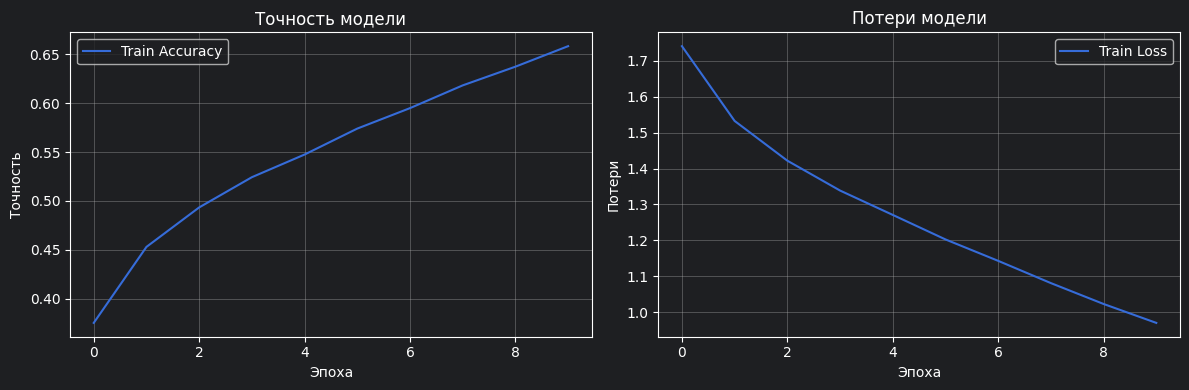

In [7]:
# TASK 5: batch normalization instead of dropouts

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

train_and_evaluate_model(build_model(), train, test);

In [ ]:
from keras.src.optimizers import AdamW
# TASK 6: free lance

from sklearn.model_selection import train_test_split

from keras import layers, models

def build_model():
    inputs = layers.Input(shape=input_shape)
    x = inputs

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs)

X_train_val, X_val, y_train_val_cat, y_val_cat = train_test_split(X_train, y_train_cat, test_size=0.1, random_state=42, stratify=y_train)

model = train_and_evaluate_model(build_model(), (X_train_val, y_train_val_cat), test, val=(X_val, y_val_cat),
                                 epochs=100, batch_size=256, optimizer=AdamW(learning_rate=1e-3, weight_decay=5e-5))



Epoch 1/100


2026-03-14 02:42:19.498351: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 140 bytes spill stores, 140 bytes spill loads

2026-03-14 02:42:19.556640: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 352 bytes spill stores, 304 bytes spill loads

2026-03-14 02:42:19.572565: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 348 bytes spill stores, 348 bytes spill loads

2026-03-14 02:42:19.757679: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 1440 bytes spill stores, 1152 bytes spill loads

2026-03-14 02:42:19.831321: I 

171/176 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1314 - loss: 2.9627

2026-03-14 02:42:25.782212: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1811', 4 bytes spill stores, 4 bytes spill loads

2026-03-14 02:42:25.913432: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 124 bytes spill stores, 124 bytes spill loads

2026-03-14 02:42:25.967861: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 384 bytes spill stores, 336 bytes spill loads

2026-03-14 02:42:26.018325: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3563', 336 bytes spill stores, 352 bytes spill loads

2026-03-14 02:42:26.132807: I extern

176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1325 - loss: 2.9430

2026-03-14 02:42:30.617567: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 580 bytes spill stores, 584 bytes spill loads

2026-03-14 02:42:30.729516: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 492 bytes spill stores, 492 bytes spill loads

2026-03-14 02:42:31.829422: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 584 bytes spill stores, 584 bytes spill loads

2026-03-14 02:42:31.971882: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 504 bytes spill stores, 504 bytes spill loads



176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.1715 - loss: 2.2679 - val_accuracy: 0.2788 - val_loss: 1.9097 - learning_rate: 0.0010
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3225 - loss: 1.7661 - val_accuracy: 0.4322 - val_loss: 1.5217 - learning_rate: 0.0010
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4498 - loss: 1.4979 - val_accuracy: 0.5332 - val_loss: 1.2888 - learning_rate: 0.0010
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5225 - loss: 1.3328 - val_accuracy: 0.5864 - val_loss: 1.1722 - learning_rate: 0.0010
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5767 - loss: 1.2033 - val_accuracy: 0.6300 - val_loss: 1.0485 - learning_rate: 0.0010
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6139 - loss: 1.1102 - val_accuracy: 0.6724 - val_loss: 0.9269 - learning_rate: 0.0010
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6455 - loss: 1.0247

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


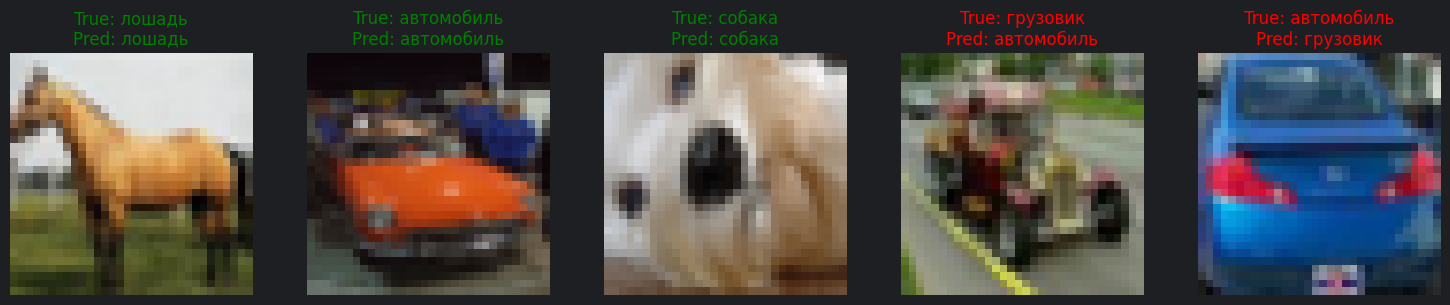

In [41]:
class_names = ['самолет', 'автомобиль', 'птица', 'кот', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Функция для визуализации предсказаний
def show_predictions(model, x_test, y_test, num_images=5):
    indices = np.random.choice(len(x_test), num_images, replace=False)

    predictions = model.predict(x_test[indices])
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = y_test[indices]

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(indices):
        axes[i].imshow(x_test[idx])
        axes[i].axis('off')

        color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
        title = f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}"
        axes[i].set_title(title, color=color)

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test)